In [1]:
# This notebook validates and visualizes meta-topic–level rating activity and
# helpfulness outcomes.

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

try:
    spark.stop()
    print("Stopped existing Spark session.")
except Exception:
    print("No active Spark session to stop.")

# Initialize Spark with large memory
spark = (
    SparkSession.builder
    .appName("meta_topic_performance_final")
    .config("spark.driver.memory", "48g")
    .config("spark.executor.memory", "48g")
    .config("spark.sql.shuffle.partitions", "400")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("Spark session active.")


No active Spark session to stop.


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/13 00:23:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark session active.


In [2]:
# ================================================================
# META-TOPIC PERFORMANCE — FINAL CORRECTED PIPELINE
# ================================================================
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import pandas as pd
import json

# ------------------------------
# 1. Load Parquet Files
# ------------------------------
topics_path = "/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/outputs/notes_topics_labeled_with_labels.parquet"
ratings_path = "/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/ratings_parquet/ratings.parquet"

notes = spark.read.parquet(topics_path)
ratings = spark.read.parquet(ratings_path)
print("Notes and ratings successfully loaded.")

# ------------------------------
# 2. Add Combined Helpful Column
# ------------------------------
ratings = ratings.withColumn(
    "any_helpful",
    F.when(F.col("helpfulnessLevel").isin("HELPFUL", "SOMEWHAT_HELPFUL"), 1).otherwise(0)
)
print("Added 'any_helpful' column for HELPFUL + SOMEWHAT_HELPFUL ratings.")

# ------------------------------
# 3. Load + Apply Permanent Meta-Topic Mapping
# ------------------------------
mapping_path = "/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/outputs/meta_topic_mapping.json"
with open(mapping_path) as f:
    meta_labels = json.load(f)

mapping_expr = F.create_map(
    *[x for pair in meta_labels.items() for x in (F.lit(pair[0]), F.lit(pair[1]))]
)

notes = notes.withColumn("meta_label", mapping_expr[F.col("topic_label")])
notes.select("topic_label", "meta_label").distinct().show(20, truncate=False)
print("Applied permanent meta-topic mapping.")

# ------------------------------
# 4. Join + Aggregate
# ------------------------------
joined = ratings.join(
    notes.select("noteId", "meta_label"),
    on="noteId",
    how="inner"
)

meta_summary = (
    joined.groupBy("meta_label")
    .agg(
        F.sum("any_helpful").alias("helpful_votes"),
        F.count("*").alias("total_ratings")
    )
    .orderBy(F.desc("total_ratings"))
)

meta_summary.show(truncate=False)

# ------------------------------
# 5. Save Summary
# ------------------------------
output_path = "/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/outputs/meta_topic_summary_fixed.parquet"
meta_summary.write.mode("overwrite").parquet(output_path)
print(f"Saved corrected meta-topic summary to {output_path}")


Notes and ratings successfully loaded.
Added 'any_helpful' column for HELPFUL + SOMEWHAT_HELPFUL ratings.


+-------------------------------------+----------------------------------------+
|topic_label                          |meta_label                              |
+-------------------------------------+----------------------------------------+
|Health, Vaccine, & Conspiracy Debunks|Public Health & Medicine                |
|Sports / Celebrity Content           |Sports, Culture, & Entertainment        |
|Meta-Deliberation / CN Norms         |Community Notes & Platform Governance   |
|Generic Spam & Reposts               |Scams, Ads, & Platform Abuse            |
|Engagement Farming / Clickbait       |Scams, Ads, & Platform Abuse            |
|Public Health / COVID                |Public Health & Medicine                |
|Commercial Spam & Policy Violations  |Scams, Ads, & Platform Abuse            |
|Crypto & Gambling Ads                |Scams, Ads, & Platform Abuse            |
|Scam Ads / Clickbait                 |Scams, Ads, & Platform Abuse            |
|Scams & Fraudulent Content 

+----------------------------------------+-------------+-------------+
|meta_label                              |helpful_votes|total_ratings|
+----------------------------------------+-------------+-------------+
|U.S. Political & Media Claims           |14500069     |24081243     |
|Policy & Governance Claims              |11641407     |20745254     |
|International Conflicts & Global Affairs|11936826     |20358684     |
|Community Notes & Platform Governance   |10855587     |18288737     |
|Sports, Culture, & Entertainment        |8971630      |13013339     |
|Public Health & Medicine                |7411957      |11562249     |
|Scams, Ads, & Platform Abuse            |1436975      |1739850      |
|Latin American Politics                 |422001       |777853       |
+----------------------------------------+-------------+-------------+



Saved corrected meta-topic summary to /project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/outputs/meta_topic_summary_fixed.parquet


In [3]:
# ------------------------------
# Sanity checks
# ------------------------------
print("Ratings rows:", ratings.count())
print("Notes rows:", notes.count())

distinct_note_ids = notes.select("noteId").distinct().count()
print("Distinct noteIds in notes:", distinct_note_ids)
print("Duplicates in notes (notes.count - distinct):", notes.count() - distinct_note_ids)


Ratings rows: 171721201
Notes rows: 1329043


Distinct noteIds in notes: 1329043
Duplicates in notes (notes.count - distinct): 0


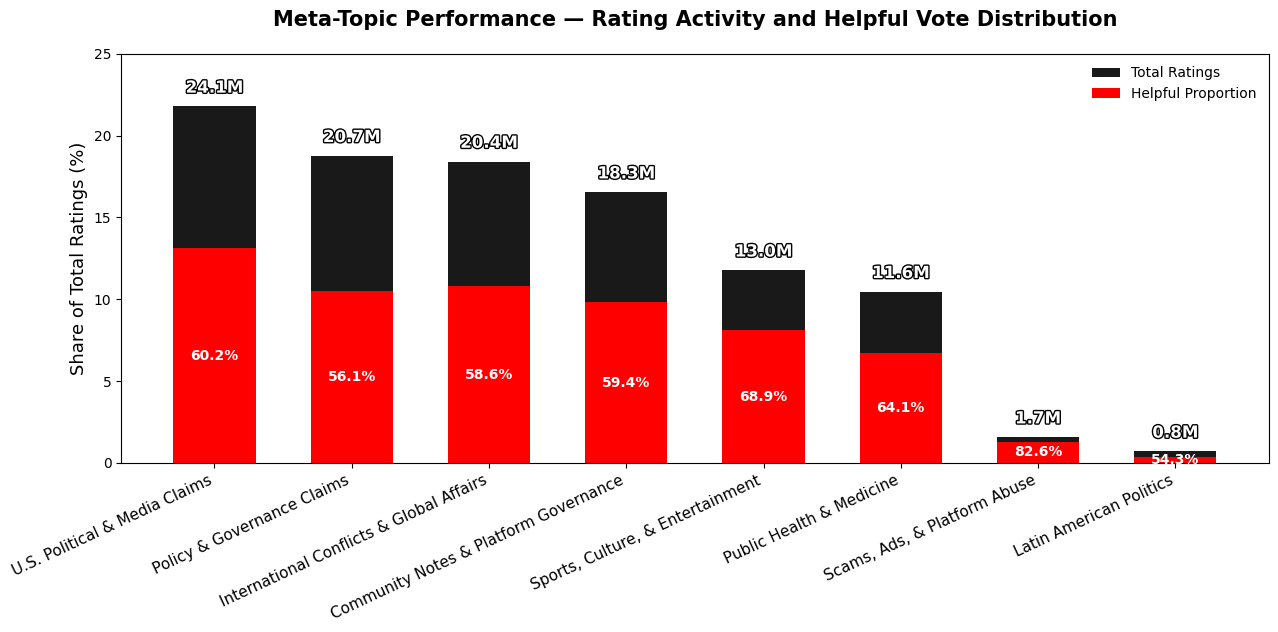

In [4]:
# ================================================================
# Figure 2 — Meta-Topic Performance
# Rating activity (share of total ratings) + helpful proportion
# ================================================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects

# --- Convert Spark -> pandas ---
meta_df = meta_summary.toPandas().dropna(subset=["meta_label"]).copy()
meta_df["helpful_votes"] = meta_df["helpful_votes"].astype(float)
meta_df["total_ratings"] = meta_df["total_ratings"].astype(float)

# --- Construct plot quantities ---
total_ratings_all = meta_df["total_ratings"].sum()

meta_df["share_of_ratings"] = (meta_df["total_ratings"] / total_ratings_all) * 100
meta_df["helpful_ratio"] = meta_df["helpful_votes"] / meta_df["total_ratings"]
meta_df["helpful_share_of_ratings"] = meta_df["share_of_ratings"] * meta_df["helpful_ratio"]
meta_df["ratings_millions"] = meta_df["total_ratings"] / 1e6

# --- Sort so bars appear in descending activity ---
meta_df = meta_df.sort_values("share_of_ratings", ascending=False).reset_index(drop=True)

# --- Plot setup ---
fig, ax = plt.subplots(figsize=(13, 6))
x = range(len(meta_df))
bar_width = 0.6

# COLORS (explicit)
COLOR_TOTAL = "black"
COLOR_HELPFUL = "red"

# --- Base bars: share of total ratings ---
bars_total = ax.bar(
    x,
    meta_df["share_of_ratings"],
    color=COLOR_TOTAL,
    alpha=0.9,
    width=bar_width,
    label="Total Ratings"
)

# --- Overlay bars: helpful share (subset of total) ---
bars_helpful = ax.bar(
    x,
    meta_df["helpful_share_of_ratings"],
    color=COLOR_HELPFUL,
    width=bar_width,
    label="Helpful Proportion"
)

# --- Axes / labels ---
ax.set_xticks(list(x))
ax.set_xticklabels(meta_df["meta_label"], rotation=25, ha="right", fontsize=11)
ax.set_ylabel("Share of Total Ratings (%)", fontsize=13)
ax.set_ylim(0, max(25, meta_df["share_of_ratings"].max() + 2))
ax.set_title(
    "Meta-Topic Performance — Rating Activity and Helpful Vote Distribution",
    fontsize=15,
    weight="bold",
    pad=20
)

# --- Label total ratings above each bar (e.g., 21.7M) ---
for i, bar in enumerate(bars_total):
    height = bar.get_height()
    label = f"{meta_df['ratings_millions'].iloc[i]:.1f}M"
    txt = ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.6,
        label,
        ha="center",
        va="bottom",
        color="white",
        fontweight="bold",
        fontsize=12,
    )
    txt.set_path_effects([
        path_effects.Stroke(linewidth=2, foreground="black"),
        path_effects.Normal(),
    ])

# --- Label helpfulness % inside the red overlay ---
for i, bar in enumerate(bars_helpful):
    helpful_pct = meta_df["helpful_ratio"].iloc[i] * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f"{helpful_pct:.1f}%",
        color="white",
        ha="center",
        va="center",
        fontweight="bold",
        fontsize=10,
    )

ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.show()


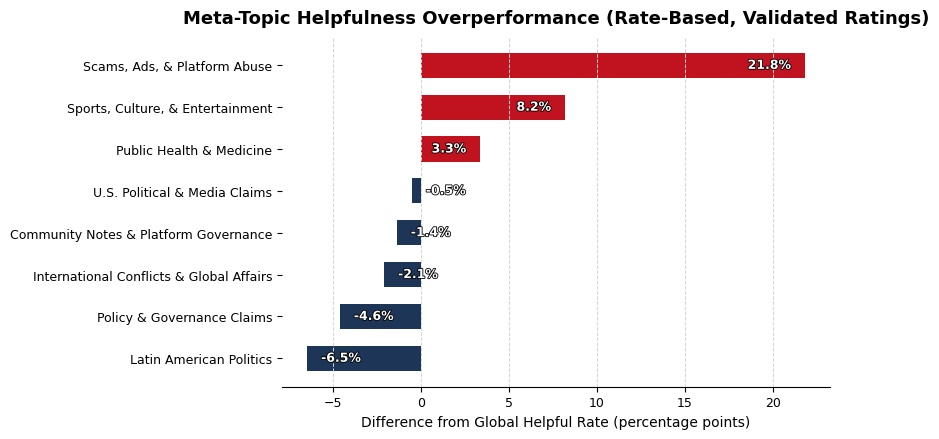

In [5]:
# ============================================================
# Meta-Topic Helpfulness Overperformance (Rate-Based Method)
# ============================================================

# ----------------------------------------------------------------
# STEP 1 — Load validated meta-topic summary
# ----------------------------------------------------------------
meta_path = (
    "/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/"
    "data/interim/outputs/meta_topic_summary_fixed.parquet"
)
df_meta = pd.read_parquet(meta_path)

# Compute helpful rate per meta-topic
df_meta["helpful_rate"] = df_meta["helpful_votes"] / df_meta["total_ratings"]

# Compute global helpful rate
global_help_rate = df_meta["helpful_votes"].sum() / df_meta["total_ratings"].sum()

# Compute overperformance as rate difference (percentage points)
df_meta["overperformance"] = (df_meta["helpful_rate"] - global_help_rate) * 100

# Sort by overperformance
df_plot = df_meta.sort_values("overperformance", ascending=True).reset_index(drop=True)

# Assign colors for clarity
df_plot["color"] = df_plot["overperformance"].apply(lambda x: "#c1121f" if x > 0 else "#1d3557")

# ----------------------------------------------------------------
# STEP 2 — Plot
# ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.5, 4.5))

bars = ax.barh(
    df_plot["meta_label"],
    df_plot["overperformance"],
    color=df_plot["color"],
    height=0.6
)

# Annotate each bar
for bar, diff in zip(bars, df_plot["overperformance"]):
    label = f"{diff:+.1f}%".replace("+", "")
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    if x > 0:
        ax.text(
            x - 0.8, y, label,
            ha="right", va="center",
            color="white", fontweight="bold", fontsize=9,
            path_effects=[
                path_effects.Stroke(linewidth=1.2, foreground="black"),
                path_effects.Normal()
            ]
        )
    else:
        ax.text(
            x + 0.8, y, label,
            ha="left", va="center",
            color="white", fontweight="bold", fontsize=9,
            path_effects=[
                path_effects.Stroke(linewidth=1.2, foreground="black"),
                path_effects.Normal()
            ]
        )

# ----------------------------------------------------------------
# STEP 3 — Styling
# ----------------------------------------------------------------
ax.set_xlabel("Difference from Global Helpful Rate (percentage points)", fontsize=10)
ax.set_ylabel("")
ax.set_title("Meta-Topic Helpfulness Overperformance (Rate-Based, Validated Ratings)",
             fontsize=13, fontweight="bold", pad=10)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.grid(axis="x", color="lightgray", linestyle="--", linewidth=0.7)
ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", labelsize=9)

plt.tight_layout()
plt.show()
